In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set display settings

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
# Import the data and show preview

df = pd.read_csv('german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
# Get column and data type info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
# Summary stats on age column

df['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [6]:
# See value counts for Risk columns particularly for class balance 

df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [7]:
# Summary stats for all cols

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Unique valus in Job column

df['Job'].unique()

array([2, 1, 3, 0], dtype=int64)

In [9]:
# Sum missing values by column

df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [10]:
# Count duplicated rows

df.duplicated().sum()

0

In [11]:
# Drop rows with na vals in checking/savings cols

df = df.dropna().reset_index(drop=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        522 non-null    int64 
 1   Age               522 non-null    int64 
 2   Sex               522 non-null    object
 3   Job               522 non-null    int64 
 4   Housing           522 non-null    object
 5   Saving accounts   522 non-null    object
 6   Checking account  522 non-null    object
 7   Credit amount     522 non-null    int64 
 8   Duration          522 non-null    int64 
 9   Purpose           522 non-null    object
 10  Risk              522 non-null    object
dtypes: int64(5), object(6)
memory usage: 45.0+ KB


In [13]:
# Get column titles

df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [14]:
# Drop additional index column

df.drop(columns = 'Unnamed: 0', inplace=True)

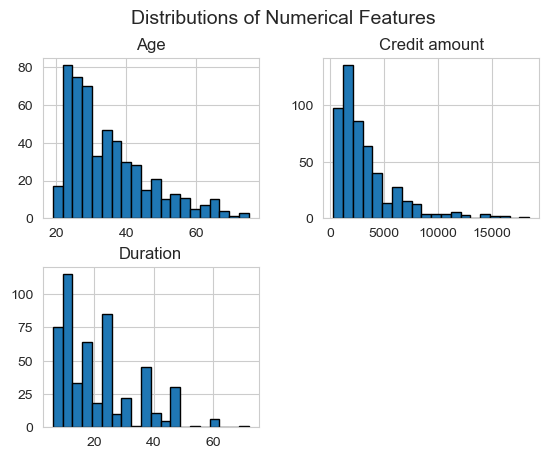

In [15]:
# Show distributions of three numeric columns

df[['Age', 'Credit amount', 'Duration']].hist(bins=20, edgecolor='black')
plt.suptitle('Distributions of Numerical Features', fontsize=14)
plt.show()

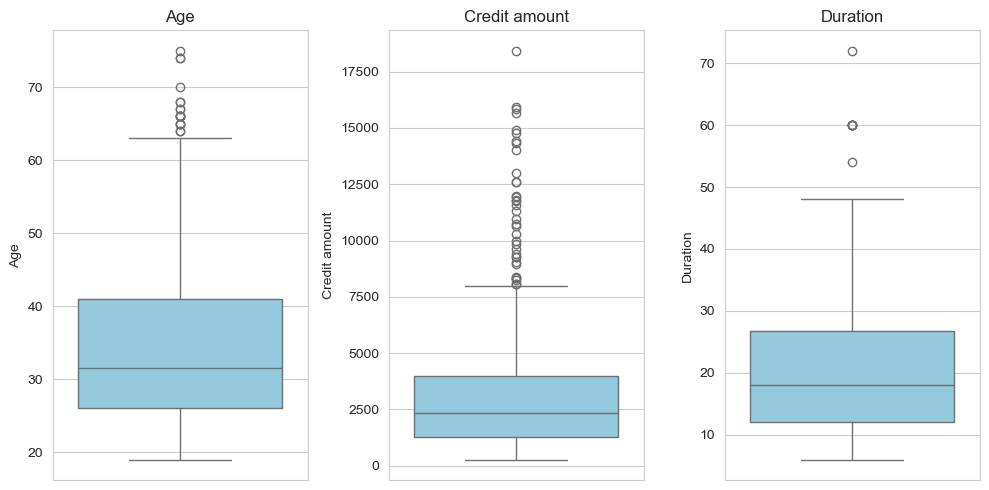

In [16]:
# Show boxplot distributions for each numerical column

plt.figure(figsize=(10,5))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1,3, i + 1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()



In [17]:
# Show rows where duration col is greater than 70

df.query('Duration > 70')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [18]:
# Show rows where duration col is greater or equal to 60

df.query('Duration >= 60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [19]:
# Define categorical columns

categorical_cols = ['Sex', 
                    'Job', 
                    'Housing', 
                    'Saving accounts', 
                    'Checking account',
                    'Purpose']

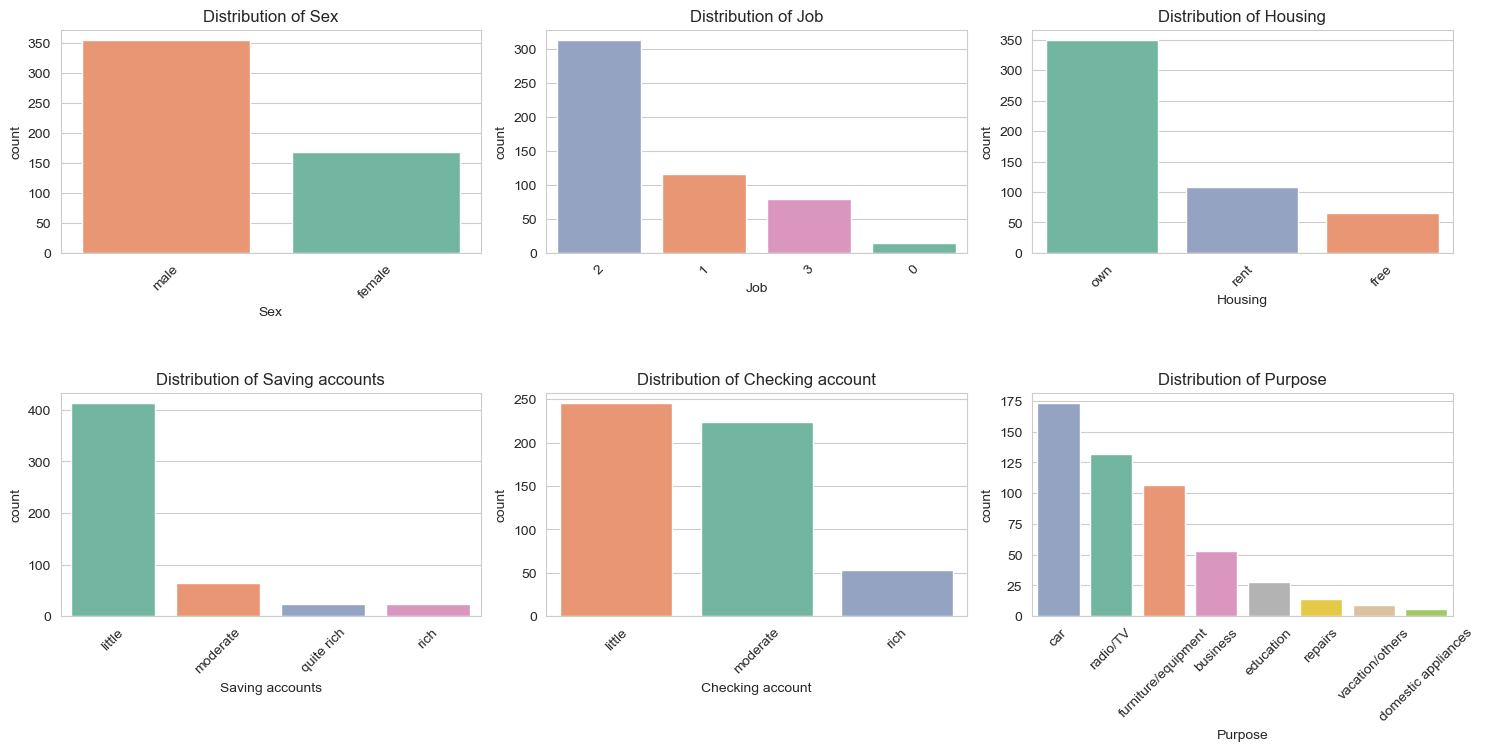

In [20]:
# Plot categorical columns 

plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3, i+1)
    sns.countplot(data=df, 
                x=col, 
                palette='Set2', 
                hue=col,
                order=df[col].value_counts().index,
                legend=False)

    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [21]:
# Create a correlation matrix

corr = df[['Age', 'Job', 'Credit amount', 'Duration']].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


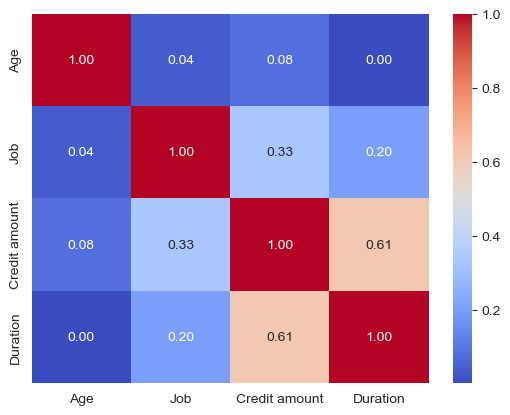

In [22]:
# Create a heatmap to visualize the correlation matrix

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [23]:
# Show mean credit amount by job

df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [24]:
# Show mean credit amount by genger

df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [25]:
# Pivot table to show credit amounts by loan purpose nad home ownership type

pd.pivot_table(df, 
        values='Credit amount', 
        index='Housing', 
        columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


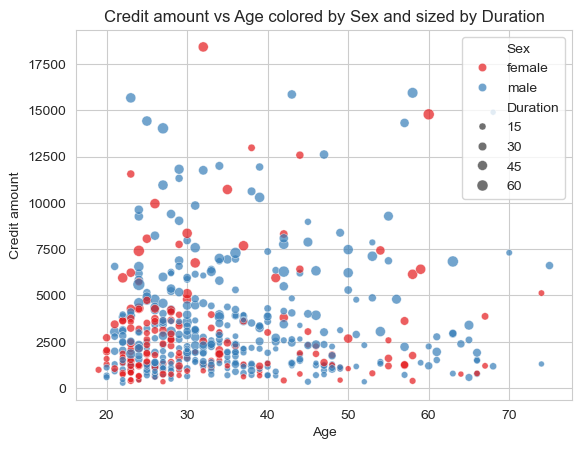

In [26]:
# See correlations between age credit amount and duartion

sns.scatterplot(data=df, 
                x='Age', 
                y='Credit amount', 
                hue='Sex',
                size='Duration',
                alpha=0.7,
                palette='Set1')
plt.title('Credit amount vs Age colored by Sex and sized by Duration')
plt.show()

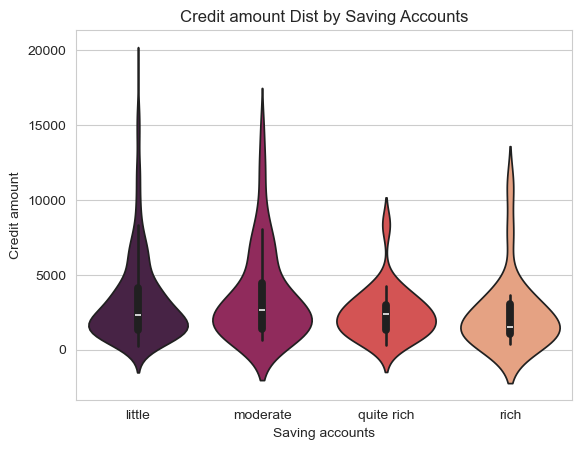

In [27]:
# Credit amount distribution across savings accounts

sns.violinplot(data=df, 
            x='Saving accounts', 
            y='Credit amount',
            palette='rocket',
            hue='Saving accounts',
            legend=False)
plt.title('Credit amount Dist by Saving Accounts')
plt.show()       

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               522 non-null    int64 
 1   Sex               522 non-null    object
 2   Job               522 non-null    int64 
 3   Housing           522 non-null    object
 4   Saving accounts   522 non-null    object
 5   Checking account  522 non-null    object
 6   Credit amount     522 non-null    int64 
 7   Duration          522 non-null    int64 
 8   Purpose           522 non-null    object
 9   Risk              522 non-null    object
dtypes: int64(4), object(6)
memory usage: 40.9+ KB


In [29]:
# Percent of total for each risk type

df["Risk"].value_counts(normalize=True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

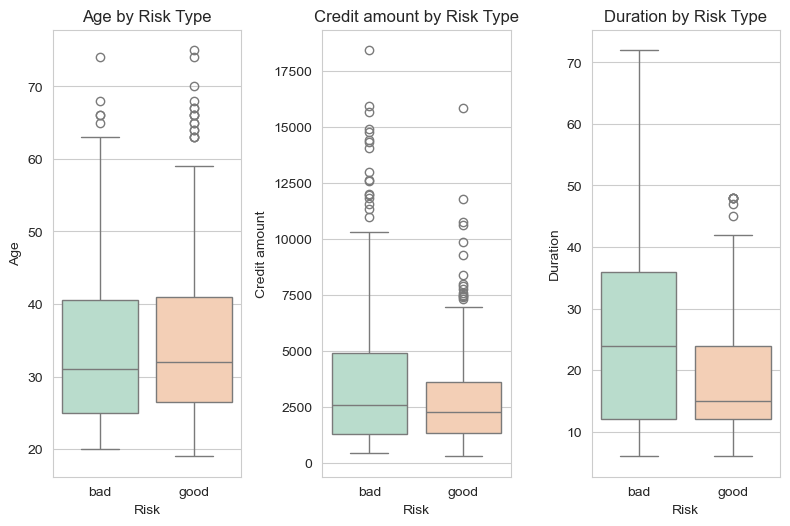

In [30]:
# Boxplots for numerical features and risk

plt.figure(figsize=(8, 15))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(3,3, i+1)
    sns.boxplot(data=df, 
                x='Risk', 
                y=col, 
                palette='Pastel2',
                hue='Risk',
                legend=False)
    plt.title(f'{col} by Risk Type')
plt.tight_layout()
plt.show()

In [31]:
# Get mean Age Credit amount, and Duration by risk type

df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


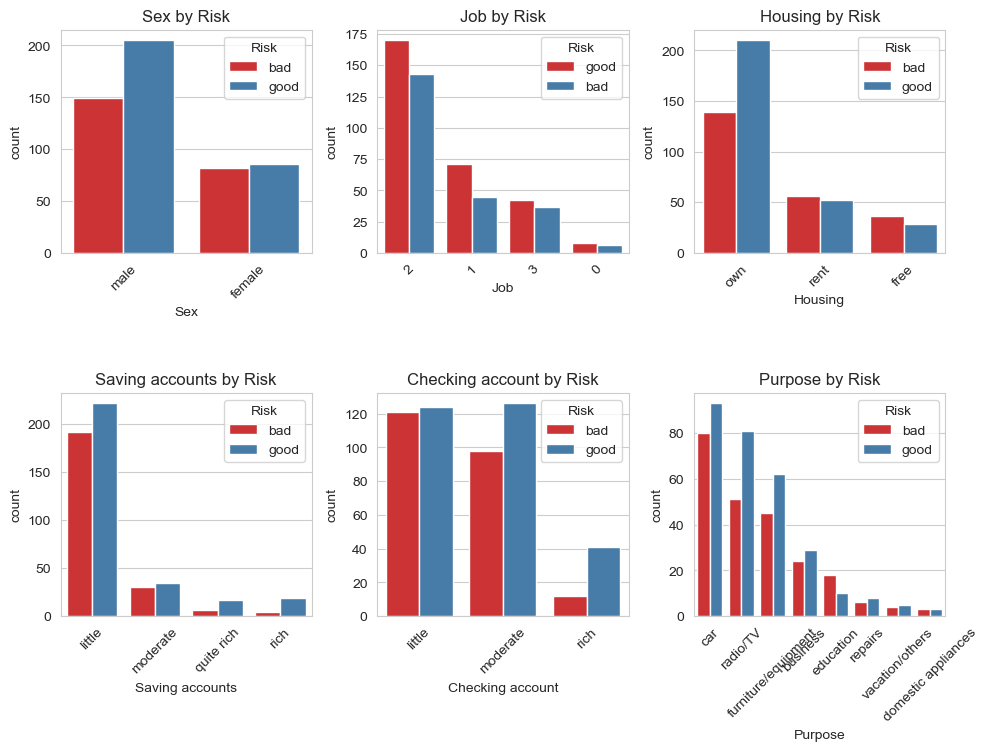

In [32]:
# Plot categorical columns by risk

plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3, i+1)
    sns.countplot(data=df, 
                x=col, 
                palette='Set1', 
                hue='Risk',
                order=df[col].value_counts().index,
                )

    plt.title(f'{col} by Risk')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Feature Engineering

In [33]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [34]:
# Designate the features to use for x in the model

features = ['Age', 
            'Sex', 
            'Job', 
            'Housing', 
            'Saving accounts', 
            'Checking account',
            'Credit amount',
            'Duration']

In [35]:
# Designate the target variable to predict

target = 'Risk'

In [36]:
# Create a dataframe for target and x variables

df_model = df[features + [target]].copy()
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad


In [37]:
# Encode categorical columns

from sklearn.preprocessing import LabelEncoder
import joblib


cat_columns = df_model.select_dtypes(include = 'object').columns.drop('Risk')

### Label Encoding is best for Ordinal Data
### One Hot Encoding is best for Nominal Data


In [38]:
# Empty dictionary for lable encoder columns

le_dict = {}

In [39]:
# Show categorical columns

cat_columns

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [ ]:
# Initalize the label encoder and transform categorical columns

for col in cat_columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    # joblib.dump(le, f'{col}_encoder.pkl')  # uncomment this

In [41]:
# Initialize label encoder for the target variable

le_target = LabelEncoder()

In [42]:
# Label encode the target variable

df_model[target] = le_target.fit_transform(df_model[target])

In [43]:
# See value counts for label encoded risk column

df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [ ]:
# Save the target encoder to a pkl file

# joblib.dump(le_target, 'target_encoder.pkl')

['target_encoder.pkl']

In [45]:
# Show Numeric values in df

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [46]:
# Import train test split for model 

from sklearn.model_selection import train_test_split


In [47]:
# Initialize x values for the model

X = df_model.drop(target, axis=1)
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [48]:
# Initialize y values for the model

y = df_model[target]
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int32

In [49]:
# Initialize train test split for model

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

In [50]:
# See shape of X_train 

X_train.shape

(417, 8)

In [51]:
# See shape of X_test

X_test.shape

(105, 8)

In [52]:
# Import models

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV


In [53]:
# Define a helper function for training and scoring models

def train_model(model, param_grid, X_train, y_train, X_test, y_test):
   grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1) 
   grid.fit(X_train, y_train)
   best_model = grid.best_estimator_
   y_pred = best_model.predict(X_test)
   acc = accuracy_score(y_test, y_pred)
   return best_model, acc, grid.best_params_

In [54]:
# Initialize model and param grid and score a decision tree model

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_param_grid = {
    'max_depth':[3,5,7,10,12,None],
    'min_samples_split':[2,5,10,12],
    'min_samples_leaf': [1, 2, 4, 6]
}

In [55]:
# Train model using the helper function defined above

best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [56]:
# Print decision tree accuracy score

print('Decsion Tree Accuracy', acc_dt)

Decsion Tree Accuracy 0.6


In [57]:
# Print the best parameters for the decsion tree

print('Best parameters', params_dt)

Best parameters {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 12}


In [58]:
# Initialize random forest model and param grid

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5,7, 10, 12, None],
    'min_samples_split': [2, 5, 10, 12],
    'min_samples_leaf': [1, 2, 4, 6]
}

In [59]:
# Train rf mode using function defined above

best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)



c:\Users\brand\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [60]:
# print rf accuracy

print('Randon Forest Accuracy', acc_rf)

Randon Forest Accuracy 0.6476190476190476


In [61]:
# Print the best parameters for the random forest model 

print('Best parameters', params_rf)

Best parameters {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 12, 'n_estimators': 100}


In [62]:
# Initialize Extra Trees model and param grid

et = ExtraTreesClassifier(random_state=42, class_weight='balanced', n_jobs=-1)

et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5,7, 10, 12, None],
    'min_samples_split': [2, 5, 10, 12],
    'min_samples_leaf': [1, 2, 4, 6]
}

In [63]:
# Train the et model

best_et, acc_et, param_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [64]:
# print Extra tree accuracy

print('Extra Trees Accuracy', acc_et)

Extra Trees Accuracy 0.6285714285714286


In [65]:
# Print the best parameters for the extra trees model 

print('Best parameters', param_et)

Best parameters {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [66]:
# Initialize XBG Model and param grid

xgb = XGBClassifier(random_state=1, 
                    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(), 
                    use_label_encoder=False, 
                    eval_metric='logloss')

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5,7, 10, 12, 15],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}

In [67]:
# Train the xgb model

best_xgb, acc_xgb, param_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

c:\Users\brand\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,
c:\Users\brand\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:40:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [68]:
# print Extra tree accuracy

print('XGB Accuracy', acc_xgb)

XGB Accuracy 0.6666666666666666


In [69]:
# Print the best parameters for the extra trees model 

print('Best parameters', param_xgb)

Best parameters {'colsample_bytree': 0.7, 'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}


In [70]:
# Export XGB model to use in streasmlit app

# joblib.dump(best_xgb, 'xgb_credit_model.pkl')

In [71]:
le = joblib.load('Sex_encoder.pkl')
print(le.classes_)

['female' 'male']
